In [5]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# WordCloud
from wordcloud import WordCloud

# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [6]:
# Download NLTK Stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SHAIKH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [7]:
df = pd.read_csv(
    "amazonreviews.tsv",
    sep='\t'
)

In [8]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [10]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [12]:
df.dropna(inplace=True)
df.isnull().sum()

label     0
review    0
dtype: int64

In [13]:
df.duplicated().sum()

0

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

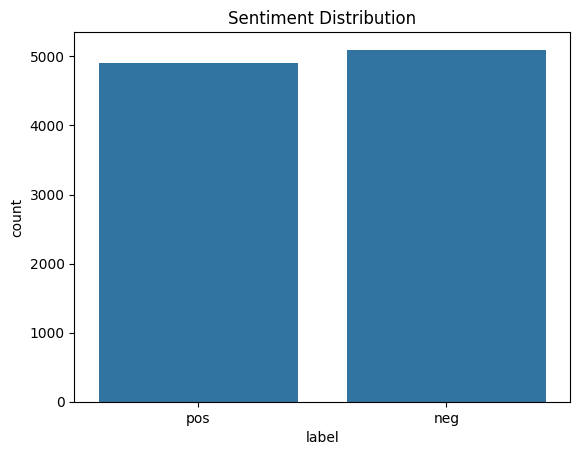

In [15]:
# Sentiment Distribution
sns.countplot(
    x='label',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

In [16]:
# Convert Labels into Numeric
df['label'] = df['label'].map({
    'pos': 1,
    'neg': 0
})

In [17]:
# Text Preprocessing
ps = PorterStemmer()

corpus = []

In [ ]:
# Cleaning Reviews
for i in range(len(df)):

    review = re.sub(
        '[^a-zA-Z]',
        ' ',
        df['review'].iloc[i]
    )

    review = review.lower()

    review = review.split()

    review = [

        ps.stem(word)

        for word in review

        if word not in stopwords.words('english')
    ]

    review = ' '.join(review)

    corpus.append(review)

In [ ]:
# Check Cleaned Reviews
corpus[:5]

In [ ]:
# Create WordCloud for Positive Reviews
positive_words = ' '.join(

    corpus[i]

    for i in range(len(corpus))

    if df['label'].iloc[i] == 1
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Review WordCloud")

plt.show()

In [ ]:
# Create WordCloud for Negative Reviews
negative_words = ' '.join(

    corpus[i]

    for i in range(len(corpus))

    if df['label'].iloc[i] == 0
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Review WordCloud")

plt.show()

In [ ]:
# TF-IDF Feature Extraction
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(corpus).toarray()

y = df['label']

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Logistic Regression Model
lr = LogisticRegression()

lr.fit(X_train, y_train)

In [ ]:
# Logistic Regression Prediction
y_pred_lr = lr.predict(X_test)

In [ ]:
# Logistic Regression Accuracy
accuracy_score(
    y_test,
    y_pred_lr
)

In [ ]:
# Logistic Regression Classification Report
print(

    classification_report(
        y_test,
        y_pred_lr
    )
)

In [ ]:
# Logistic Regression F1 Score
f1_score(
    y_test,
    y_pred_lr
)

In [ ]:
# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# SVM Model
svm = SVC()

svm.fit(X_train, y_train)

In [ ]:
# SVM Prediction
y_pred_svm = svm.predict(X_test)

In [ ]:
# SVM Accuracy
accuracy_score(
    y_test,
    y_pred_svm
)

In [ ]:
# SVM Classification Report
print(

    classification_report(
        y_test,
        y_pred_svm
    )
)

In [ ]:
# SVM F1 Score
f1_score(
    y_test,
    y_pred_svm
)

In [ ]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
Step 31: Cross Validati

In [ ]:
#Cross Validation
#Logistic Regression
lr_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5
)

print(
    "Logistic Regression CV Mean:",
    lr_scores.mean()
)

In [ ]:
# SVM
svm_scores = cross_val_score(
    svm,
    X,
    y,
    cv=5
)

print(
    "SVM CV Mean:",
    svm_scores.mean()
)

In [ ]:
# Model Comparison
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [

        accuracy_score(
            y_test,
            y_pred_lr
        ),

        accuracy_score(
            y_test,
            y_pred_svm
        )
    ],

    'F1 Score': [

        f1_score(
            y_test,
            y_pred_lr
        ),

        f1_score(
            y_test,
            y_pred_svm
        )
    ]
})

print(comparison)

# Final Conclusion
print("""

The sentiment analysis system was successfully
implemented using NLP and Machine Learning.

Text preprocessing improved data quality.

TF-IDF converted text into numerical vectors.

Logistic Regression and SVM models were used
for sentiment classification.

The models achieved strong accuracy and F1 scores.

This system can help e-commerce companies
monitor customer feedback automatically
and improve customer satisfaction.

""")